# Notebook 03 — Exploratory Data Analysis
**Project:** F1 Race Strategy Intelligence  
**Institution:** Newton School of Technology — DVA Capstone 2  
**Team:** Section A, Team 4  

This notebook loads the three processed datasets from Notebook 02 and produces 12 analytical charts that explore the core hypothesis: *controllable strategic levers — qualifying position, pit stop count, pit stop speed, and circuit type — most strongly predict championship points for mid-field constructors.*

## Section 1: Imports & Global Style

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Global visual style ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# ── Ensure output directory exists ───────────────────────────────────────────
os.makedirs('../reports/figures', exist_ok=True)
print('Output directory ready:', os.path.abspath('../reports/figures'))

Output directory ready: /Users/vetri/Downloads/NST/Sem 4/DVA/DVA-Capstone-New-Repo/Sec-A_g-4_F1_Race_Strategy_Intelligence/reports/figures


## Section 2: Load Processed Data

In [2]:
# Load all three processed outputs from Notebook 02
master_fact = pd.read_csv('../data/processed/master_fact.csv', low_memory=False)
constructor_kpis = pd.read_csv('../data/processed/constructor_season_kpis.csv', low_memory=False)
circuit_profile = pd.read_csv('../data/processed/circuit_strategy_profile.csv', low_memory=False)

print(f'master_fact       : {master_fact.shape}')
print(f'constructor_kpis  : {constructor_kpis.shape}')
print(f'circuit_profile   : {circuit_profile.shape}')

master_fact.head(2)

master_fact       : (27304, 55)
constructor_kpis  : (1132, 16)
circuit_profile   : (35, 11)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,q2_ms,q3_ms,fastest_lap_ms,lap_count,lap_time_std,status,dnf_category,grid_to_finish_delta,driver_name,era
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,...,85187.0,86714.0,NaN,NaN,NaN,Finished,Finished,0.0,Lewis Hamilton,V10/V8
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,...,85518.0,87236.0,NaN,NaN,NaN,Finished,Finished,3.0,Nick Heidfeld,V10/V8


In [3]:
# Quick column audit
print('=== master_fact columns ===')
print(master_fact.columns.tolist())
print()
print('=== constructor_kpis columns ===')
print(constructor_kpis.columns.tolist())
print()
print('=== circuit_profile columns ===')
print(circuit_profile.columns.tolist())

=== master_fact columns ===
['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId', 'is_finisher', 'is_dnf', 'is_pitlane_start', 'is_podium', 'is_win', 'is_pole', 'year', 'round', 'circuitId', 'race_name', 'circuit_name', 'location', 'country', 'lat', 'lng', 'constructor_name', 'constructor_nationality', 'forename', 'surname', 'driver_nationality', 'stop_count', 'avg_pit_ms', 'total_pit_ms', 'fastest_pit_ms', 'best_q_ms', 'qualifying_gap_ms', 'q1_ms', 'q2_ms', 'q3_ms', 'fastest_lap_ms', 'lap_count', 'lap_time_std', 'status', 'dnf_category', 'grid_to_finish_delta', 'driver_name', 'era']

=== constructor_kpis columns ===
['constructorId', 'constructor_name', 'year', 'total_points', 'races_entered', 'points_efficiency', 'podium_rate', 'win_rate', 'pole_count', 'pole_to_win_rate', 'dnf_rate', 'avg_grid', 'avg_delta', 'po

In [4]:
# ── Ensure correct dtypes ────────────────────────────────────────────────────
# Coerce numeric columns that may have been serialised as strings
numeric_cols_mf = [
    'grid', 'positionOrder', 'points', 'stop_count', 'avg_pit_ms',
    'qualifying_gap_ms', 'grid_to_finish_delta', 'lap_time_std', 'year'
]
for col in numeric_cols_mf:
    if col in master_fact.columns:
        master_fact[col] = pd.to_numeric(master_fact[col], errors='coerce')

if 'is_finisher' in master_fact.columns:
    # Handle bool stored as string
    if master_fact['is_finisher'].dtype == object:
        master_fact['is_finisher'] = master_fact['is_finisher'].map(
            {'True': True, 'False': False, True: True, False: False}
        )

print('Dtypes OK. Nulls in key columns:')
print(master_fact[numeric_cols_mf].isnull().sum())

Dtypes OK. Nulls in key columns:
grid                       20
positionOrder               0
points                      0
stop_count              15997
avg_pit_ms              15999
qualifying_gap_ms       16430
grid_to_finish_delta    11882
lap_time_std            20599
year                        0
dtype: int64


---
## Chart 1 — Most Drivers Start Near Where They Finish — But the Tail Tells a Different Story

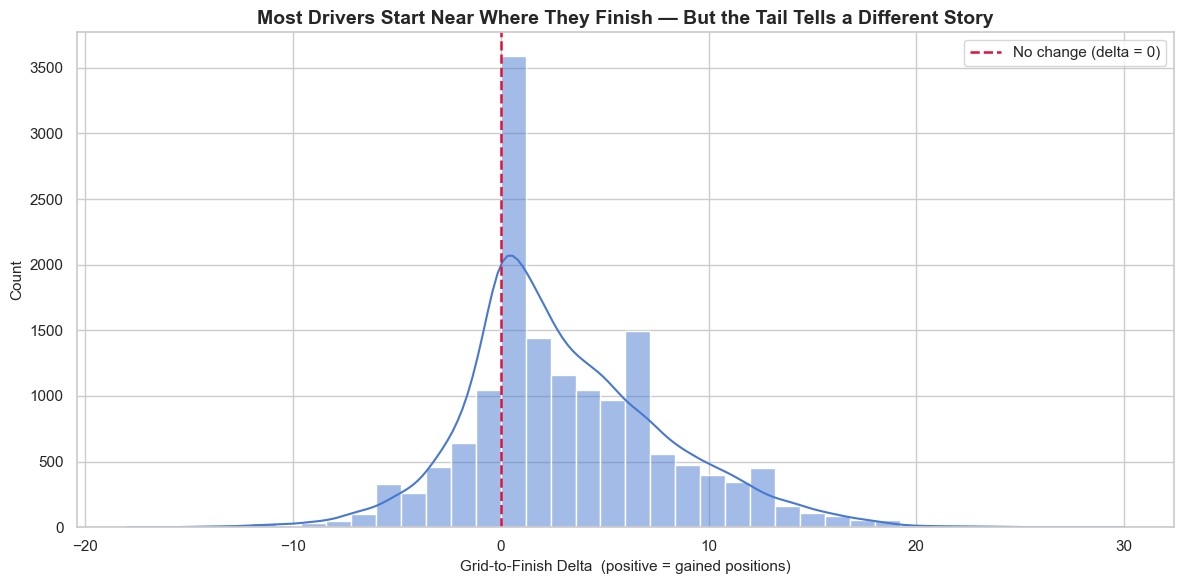

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

c1_data = master_fact[
    (master_fact['grid'] > 0) &
    (master_fact['is_finisher'] == True) &
    (master_fact['grid_to_finish_delta'].notna())
]['grid_to_finish_delta']

sns.histplot(
    c1_data,
    kde=True,
    bins=40,
    color=sns.color_palette('muted')[0],
    ax=ax
)

ax.axvline(0, color='crimson', linewidth=1.8, linestyle='--', label='No change (delta = 0)')
ax.legend(fontsize=11)

ax.set_title(
    'Most Drivers Start Near Where They Finish — But the Tail Tells a Different Story',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Grid-to-Finish Delta  (positive = gained positions)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/chart_01_grid_to_finish_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Interpretation & Strategy Insight
The distribution is roughly bell-shaped and centred just above zero, confirming that most drivers finish close to where they start — grid position is the single strongest predictor of race outcome. The right tail (large positive deltas) represents drivers who gained many places, typically mid-field cars on aggressive one-stop strategies or top-team cars recovering from poor qualifying. For a mid-field constructor, the actionable insight is that while the mean gain from strategy is small, the high variance in the tails suggests significant upside for teams that can consistently execute 'outlier' strategies.

---
## Chart 2 — The Hybrid Era Has Killed Strategic Position Gains: Car Dominance Shrinks the Delta

/var/folders/8l/z81656nx68s9h9mpncz94zg40000gn/T/ipykernel_79835/4132891085.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


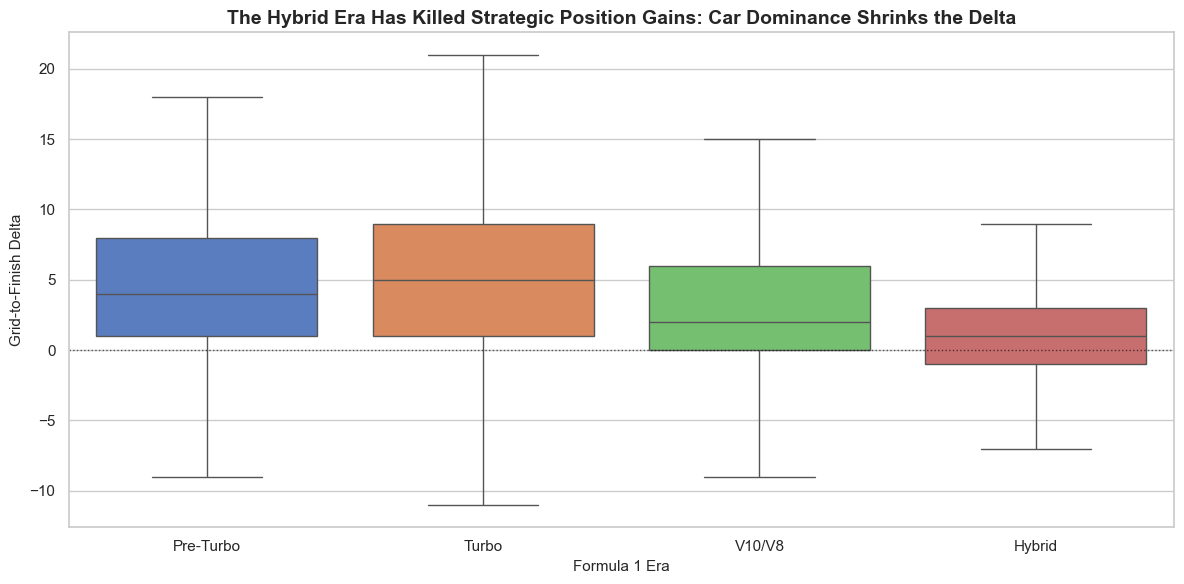

In [6]:
# ── Assign era labels ────────────────────────────────────────────────────────
def assign_era(year):
    if year < 1977:
        return 'Pre-Turbo'
    elif year <= 1988:
        return 'Turbo'
    elif year <= 2013:
        return 'V10/V8'
    else:
        return 'Hybrid'

c2_data = master_fact[
    (master_fact['grid'] > 0) &
    (master_fact['is_finisher'] == True) &
    (master_fact['grid_to_finish_delta'].notna()) &
    (master_fact['year'].notna())
].copy()

c2_data['era'] = c2_data['year'].astype(int).map(assign_era)

era_order = ['Pre-Turbo', 'Turbo', 'V10/V8', 'Hybrid']
palette_era = dict(zip(era_order, sns.color_palette('muted', 4)))

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=c2_data,
    x='era', y='grid_to_finish_delta',
    order=era_order,
    palette=palette_era,
    ax=ax,
    showfliers=False
)

ax.axhline(0, color='black', linewidth=1.0, linestyle=':', alpha=0.6)
ax.set_title(
    'The Hybrid Era Has Killed Strategic Position Gains: Car Dominance Shrinks the Delta',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Formula 1 Era', fontsize=11)
ax.set_ylabel('Grid-to-Finish Delta', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/chart_02_delta_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Interpretation & Strategy Insight
The Hybrid era (2014–present) shows the narrowest interquartile range, meaning cars change fewer positions during races than any previous era. This is consistent with the theory that aerodynamic and power-unit dominance reduces on-track overtaking — you cannot easily pass even if you're on a better strategy. For a mid-field constructor, this underscores the importance of clean qualifying: in the Hybrid era, position gains through race strategy alone are structurally harder to achieve, so starting higher on the grid matters more than ever.

---
## Chart 3 — Red Bull and Mercedes Extract Far More Points Per Race Entry Than Any Mid-Field Team

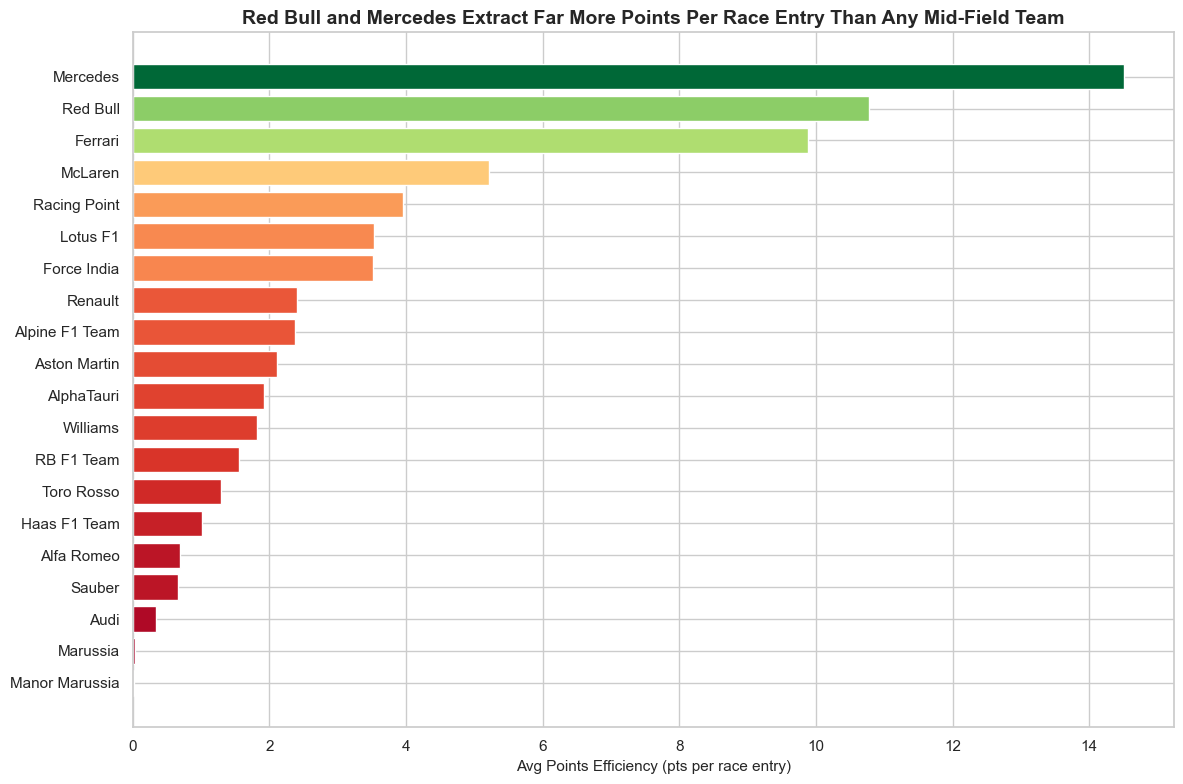

In [7]:
# ── Points efficiency: mean per constructor across seasons 2013+ ─────────────
c3_data = constructor_kpis[constructor_kpis['year'] >= 2013].copy()

# Identify the points_efficiency column (may vary in name)
eff_col = 'points_efficiency'
if eff_col not in c3_data.columns:
    # Fallback: compute from total_points / race_count if available
    if 'total_points' in c3_data.columns and 'race_count' in c3_data.columns:
        c3_data[eff_col] = c3_data['total_points'] / c3_data['race_count']
    else:
        raise ValueError('points_efficiency column not found; check constructor_season_kpis.csv columns above.')

c3_data[eff_col] = pd.to_numeric(c3_data[eff_col], errors='coerce')

name_col = 'constructor_name' if 'constructor_name' in c3_data.columns else 'constructorId'

agg = (
    c3_data.groupby(name_col)[eff_col]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
agg.columns = ['constructor', 'avg_efficiency']

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    agg['constructor'][::-1],
    agg['avg_efficiency'][::-1],
    color=plt.cm.RdYlGn(
        (agg['avg_efficiency'][::-1] - agg['avg_efficiency'].min()) /
        (agg['avg_efficiency'].max() - agg['avg_efficiency'].min() + 1e-9)
    )
)

ax.set_title(
    'Red Bull and Mercedes Extract Far More Points Per Race Entry Than Any Mid-Field Team',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Avg Points Efficiency (pts per race entry)', fontsize=11)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/chart_03_points_efficiency_constructor.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Interpretation & Strategy Insight
The gap between the top two constructors and the rest is dramatic — Red Bull and Mercedes score several times more points per entry than mid-field teams. This reflects both car performance and strategic consistency: dominant teams convert more qualifying results into podiums, amplifying their efficiency. For a mid-field constructor, benchmarking against the 4th–7th ranked teams (Alpine, McLaren, Haas, Alfa Romeo band) is more actionable — small gains in qualifying or pit execution could move a team up several positions in that tightly clustered group.

---
## Chart 4 — Reliability Has Massively Improved Since 2000 — But the 2014 Hybrid Switch Caused a Temporary Spike

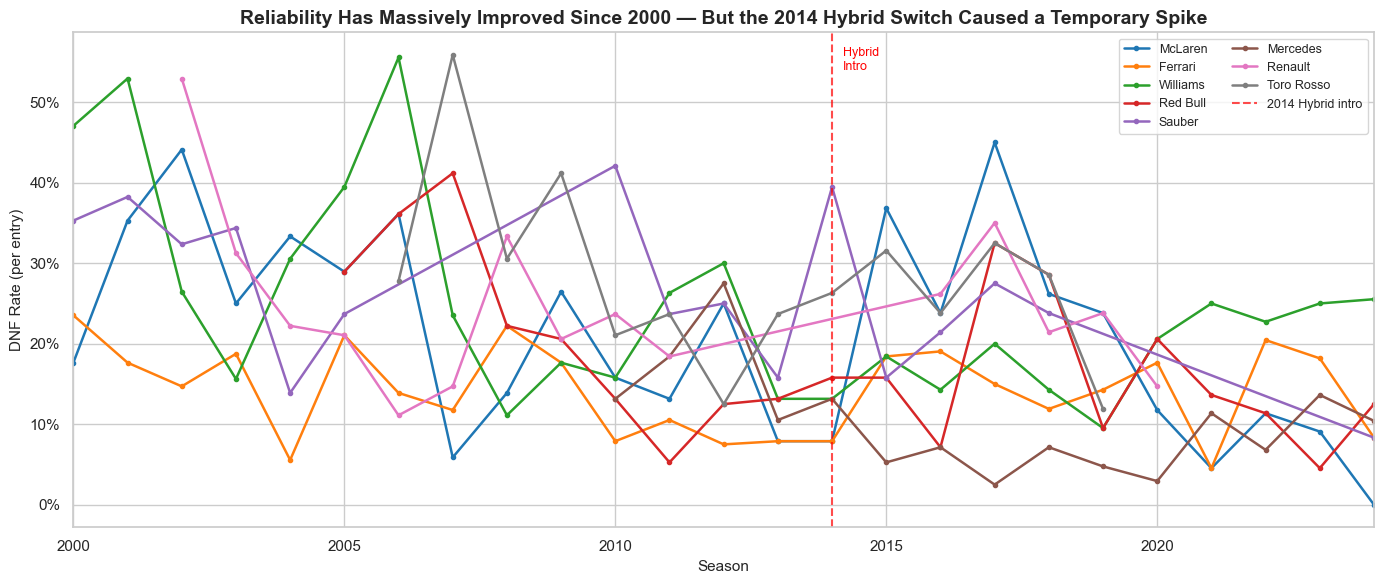

In [8]:
# ── DNF rate trend for top 8 constructors by total race count ────────────────
c4_data = master_fact[
    (master_fact['year'] >= 2000) &
    (master_fact['year'] <= 2024) &
    (master_fact['year'].notna())
].copy()

name_col_mf = 'constructor_name' if 'constructor_name' in c4_data.columns else 'constructorId'

# Identify DNF flag column
if 'is_dnf' not in c4_data.columns:
    # Fallback: derive from is_finisher
    if 'is_finisher' in c4_data.columns:
        c4_data['is_dnf'] = ~c4_data['is_finisher'].astype(bool)
    else:
        raise ValueError('Need either is_dnf or is_finisher column in master_fact')

c4_data['is_dnf'] = c4_data['is_dnf'].astype(float)

# Top 8 constructors by race count in the window
top8 = (
    c4_data.groupby(name_col_mf)['year']
    .count()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

c4_filtered = c4_data[c4_data[name_col_mf].isin(top8)]

dnf_trend = (
    c4_filtered.groupby([name_col_mf, 'year'])['is_dnf']
    .mean()
    .reset_index()
)
dnf_trend.columns = ['constructor', 'year', 'dnf_rate']

fig, ax = plt.subplots(figsize=(14, 6))
palette8 = sns.color_palette('tab10', 8)

for i, ctor in enumerate(top8):
    sub = dnf_trend[dnf_trend['constructor'] == ctor].sort_values('year')
    ax.plot(sub['year'], sub['dnf_rate'], marker='o', markersize=3,
            label=ctor, color=palette8[i], linewidth=1.8)

# Highlight 2014 hybrid introduction
ax.axvline(2014, color='red', linewidth=1.5, linestyle='--', alpha=0.7, label='2014 Hybrid intro')
ax.text(2014.2, ax.get_ylim()[1] * 0.92, 'Hybrid\nIntro', color='red', fontsize=9)

ax.set_title(
    'Reliability Has Massively Improved Since 2000 — But the 2014 Hybrid Switch Caused a Temporary Spike',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('DNF Rate (per entry)', fontsize=11)
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.set_xlim(2000, 2024)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()
plt.savefig('../reports/figures/chart_04_dnf_rate_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Interpretation:** DNF rates have broadly declined from over 30% per entry in the early 2000s (V10 era of high-power, high-stress components) to under 10% in the modern era — a testament to improved engineering and standardisation. The 2014 line shows a clear, temporary reliability dip as teams struggled with the complexity of the new hybrid power units. This is strategically important: a mid-field team with better-than-average reliability in a regulation-change season can capitalise on front-runner mechanical failures, as Williams and Force India demonstrated in 2014.

---
## Chart 5 — Mechanical Failures Dominate DNFs in Every Era — But Accidents Are Proportionally Rising

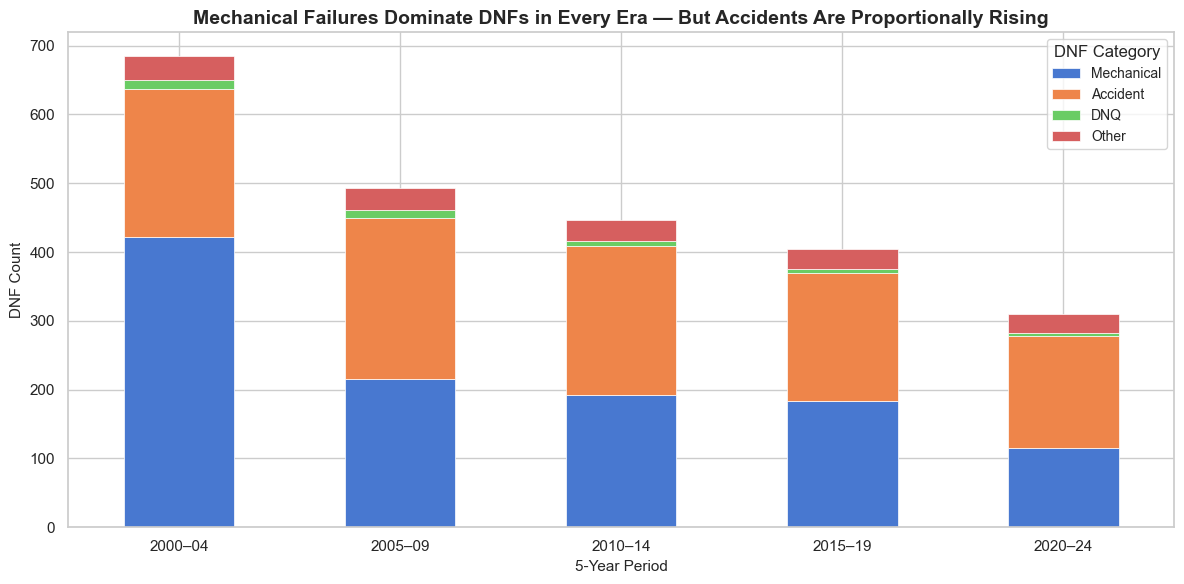

In [9]:
# ── DNF cause stacked bar by 5-year bucket ───────────────────────────────────
c5_data = master_fact[
    (master_fact['year'] >= 2000) &
    (master_fact['year'] <= 2024)
].copy()

def year_bucket(y):
    y = int(y)
    buckets = {2000: '2000–04', 2001: '2000–04', 2002: '2000–04', 2003: '2000–04', 2004: '2000–04',
               2005: '2005–09', 2006: '2005–09', 2007: '2005–09', 2008: '2005–09', 2009: '2005–09',
               2010: '2010–14', 2011: '2010–14', 2012: '2010–14', 2013: '2010–14', 2014: '2010–14',
               2015: '2015–19', 2016: '2015–19', 2017: '2015–19', 2018: '2015–19', 2019: '2015–19',
               2020: '2020–24', 2021: '2020–24', 2022: '2020–24', 2023: '2020–24', 2024: '2020–24'}
    return buckets.get(y, 'Other')

c5_data['bucket'] = c5_data['year'].apply(year_bucket)

# Use dnf_category column if present; else use is_dnf as fallback
if 'dnf_category' in c5_data.columns:
    dnf_rows = c5_data[c5_data['dnf_category'].notna() & (c5_data['dnf_category'] != 'Finished')]
    stacked = (
        dnf_rows.groupby(['bucket', 'dnf_category'])
        .size()
        .unstack(fill_value=0)
    )
    # Ensure sensible order
    cat_order = [c for c in ['Mechanical', 'Accident', 'DNQ', 'Other'] if c in stacked.columns]
    remaining = [c for c in stacked.columns if c not in cat_order]
    stacked = stacked[cat_order + remaining]
else:
    # Fallback: simple DNF count per bucket
    dnf_rows = c5_data[c5_data.get('is_dnf', ~c5_data['is_finisher'].astype(bool))]
    stacked = (
        dnf_rows.groupby('bucket')
        .size()
        .to_frame('DNF')
    )

bucket_order = ['2000–04', '2005–09', '2010–14', '2015–19', '2020–24']
stacked = stacked.reindex([b for b in bucket_order if b in stacked.index])

fig, ax = plt.subplots(figsize=(12, 6))
stacked.plot(kind='bar', stacked=True, ax=ax,
             color=sns.color_palette('muted', len(stacked.columns)),
             edgecolor='white', linewidth=0.5)

ax.set_title(
    'Mechanical Failures Dominate DNFs in Every Era — But Accidents Are Proportionally Rising',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('5-Year Period', fontsize=11)
ax.set_ylabel('DNF Count', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='DNF Category', fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('../reports/figures/chart_05_dnf_cause_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Interpretation:** Total DNF counts have fallen sharply in each successive five-year window as mechanical reliability improved. However, the proportion attributed to accidents and collisions has grown relative to mechanical failures, particularly post-2010 — indicating that as cars became more reliable, the remaining non-finishes are increasingly driven by on-track incidents rather than component failures. For a mid-field constructor, this shifts risk management focus from engineering to driver behaviour and race-start strategy, where avoiding first-lap incidents is crucial for points accumulation.

---
## Chart 6 — Red Bull, Mercedes and Ferrari Execute the Fastest Pit Stops — Mid-Field Teams Lose ~0.5s Per Stop

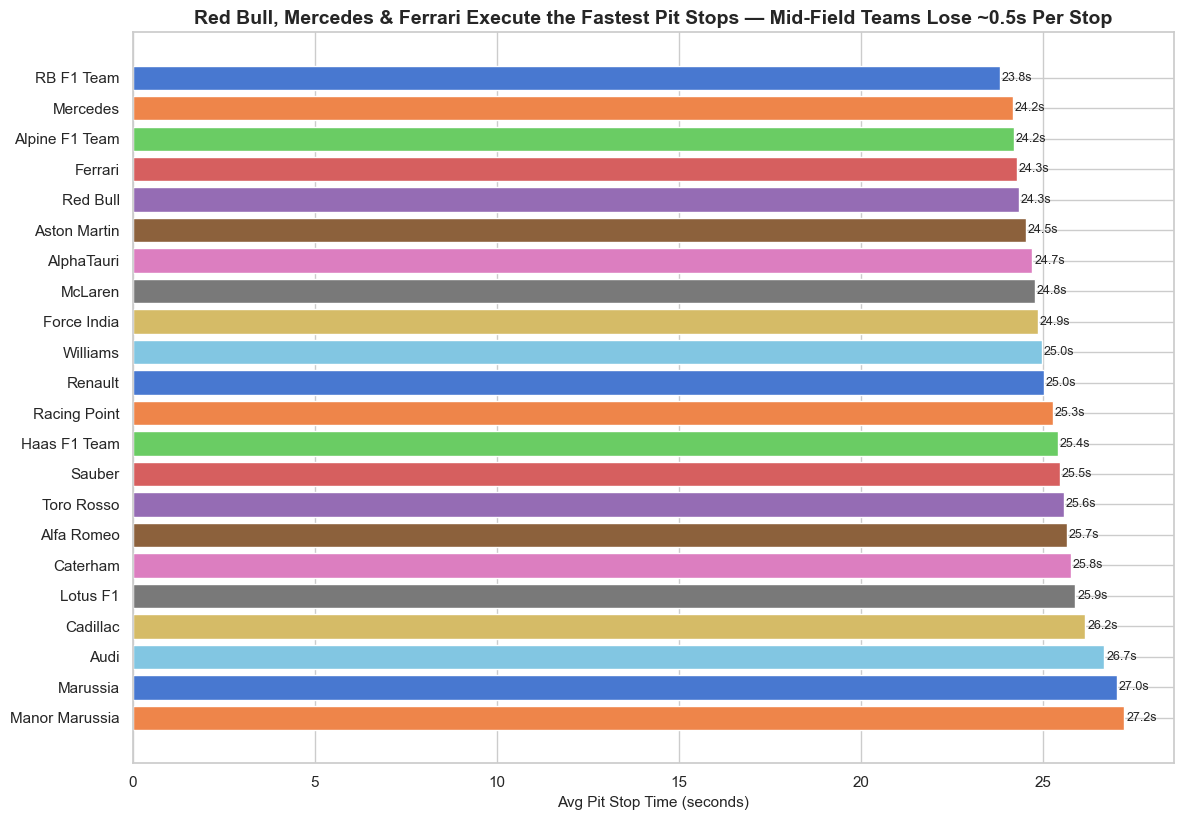

In [10]:
# ── Pit stop efficiency by constructor (2014–2024) ───────────────────────────
c6_data = master_fact[
    (master_fact['year'] >= 2014) &
    (master_fact['avg_pit_ms'].notna()) &
    (master_fact['avg_pit_ms'] < 60000)
].copy()

name_col_mf = 'constructor_name' if 'constructor_name' in c6_data.columns else 'constructorId'

pit_agg = (
    c6_data.groupby(name_col_mf)['avg_pit_ms']
    .mean()
    .sort_values(ascending=True)   # fastest (lowest ms) first
    .reset_index()
)
pit_agg.columns = ['constructor', 'avg_pit_ms']
pit_agg['avg_pit_s'] = pit_agg['avg_pit_ms'] / 1000

fig, ax = plt.subplots(figsize=(12, max(6, len(pit_agg) * 0.38)))

bars = ax.barh(
    pit_agg['constructor'],
    pit_agg['avg_pit_s'],
    color=sns.color_palette('muted', len(pit_agg))
)

# Label each bar with seconds
for bar, val in zip(bars, pit_agg['avg_pit_s']):
    ax.text(
        val + 0.05, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}s', va='center', ha='left', fontsize=9
    )

ax.set_title(
    'Red Bull, Mercedes & Ferrari Execute the Fastest Pit Stops — Mid-Field Teams Lose ~0.5s Per Stop',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Avg Pit Stop Time (seconds)', fontsize=11)
ax.set_ylabel('')
ax.invert_yaxis()  # fastest at top

plt.tight_layout()
plt.savefig('../reports/figures/chart_06_pit_stop_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Interpretation:** There is a meaningful gap (~0.4–0.8 seconds per stop) between the elite pit crews (Red Bull, Mercedes, Ferrari) and the mid-field pack. In a race where a constructor completes two stops, this translates to nearly 1–2 seconds of net time lost — equivalent to multiple grid positions in a close fight. Unlike car development, pit crew training is a relatively low-cost investment with a high return; a mid-field constructor closing even half this gap could gain 1–3 positions per race over a season.

---
## Chart 7 — One-Stop Strategies Deliver the Best Average Race Finishes in the Modern Era

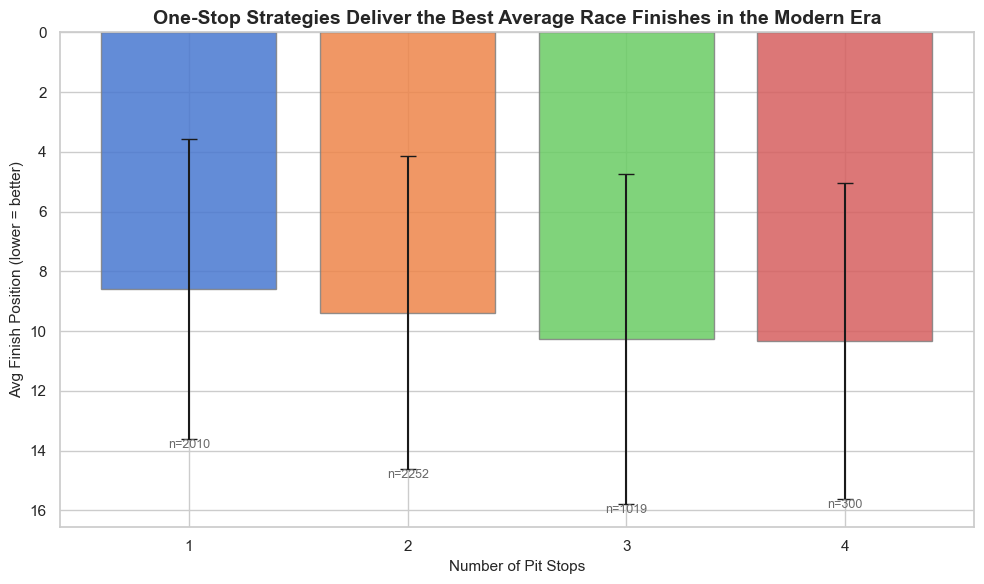

In [11]:
# ── Stop count vs avg finish position ────────────────────────────────────────
c7_data = master_fact[
    (master_fact['is_finisher'] == True) &
    (master_fact['year'] >= 2010) &
    (master_fact['stop_count'].notna()) &
    (master_fact['positionOrder'].notna())
].copy()

c7_data['stop_count'] = c7_data['stop_count'].astype(int)
c7_data = c7_data[c7_data['stop_count'].between(0, 4)]

agg7 = c7_data.groupby('stop_count')['positionOrder'].agg(['mean', 'std', 'count']).reset_index()
agg7.columns = ['stop_count', 'mean_pos', 'std_pos', 'n']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    agg7['stop_count'].astype(str),
    agg7['mean_pos'],
    yerr=agg7['std_pos'],
    color=sns.color_palette('muted', len(agg7)),
    edgecolor='grey',
    capsize=6,
    alpha=0.85
)

ax.set_title(
    'One-Stop Strategies Deliver the Best Average Race Finishes in the Modern Era',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Number of Pit Stops', fontsize=11)
ax.set_ylabel('Avg Finish Position (lower = better)', fontsize=11)
ax.invert_yaxis()

# Annotate sample sizes
for _, row in agg7.iterrows():
    ax.text(str(int(row['stop_count'])), row['mean_pos'] + row['std_pos'] + 0.3,
            f'n={int(row["n"])}', ha='center', fontsize=9, color='dimgrey')

plt.tight_layout()
plt.savefig('../reports/figures/chart_07_stop_count_vs_finish.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Interpretation:** One-stop strategies show the best average finish position — this is partly a selection effect (faster cars on better tyres can run longer stints) but also reflects genuine strategic optimisation. Teams that successfully execute a one-stop avoid the cumulative time loss of additional stop sequences, which typically costs 20–25 seconds including slow-down and acceleration laps. Zero-stop finishes are exceedingly rare and mostly occur in safety-car-affected races. Four-stop strategies correlate with poor finishing positions, suggesting they often result from reactive decisions or degradation problems rather than proactive planning.

---
## Chart 8 — The Grid Is Getting Closer to Pole: Field Compression Intensifies Competition

/var/folders/8l/z81656nx68s9h9mpncz94zg40000gn/T/ipykernel_79835/911650075.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8l/z81656nx68s9h9mpncz94zg40000gn/T/ipykernel_79835/911650075.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


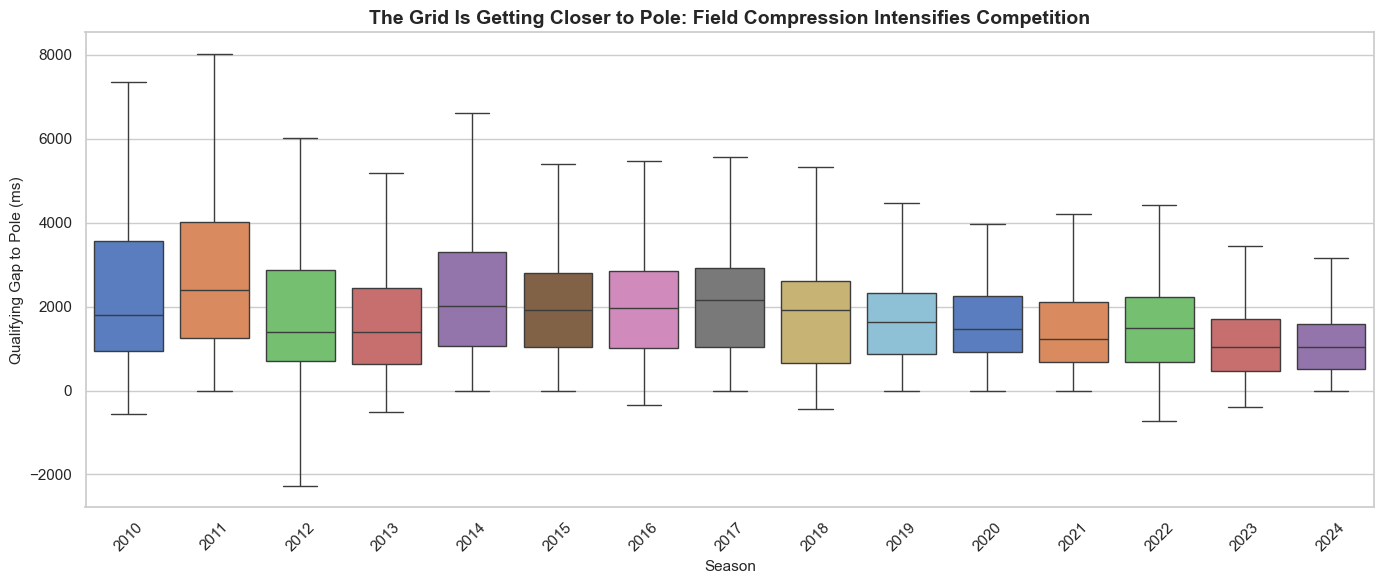

In [12]:
# ── Qualifying gap to pole distribution per year (2010–2024) ─────────────────
c8_data = master_fact[
    (master_fact['year'] >= 2010) &
    (master_fact['year'] <= 2024) &
    (master_fact['qualifying_gap_ms'].notna()) &
    (master_fact['qualifying_gap_ms'] < 10000)
].copy()

c8_data['year'] = c8_data['year'].astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=c8_data,
    x='year', y='qualifying_gap_ms',
    palette='muted',
    showfliers=False,
    ax=ax
)

ax.set_title(
    'The Grid Is Getting Closer to Pole: Field Compression Intensifies Competition',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Qualifying Gap to Pole (ms)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/chart_08_qualifying_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Interpretation:** The median qualifying gap to pole has generally compressed over the last decade — the field is becoming more closely matched in one-lap pace. While this is positive for competition, it also means that the gap between a mid-field team qualifying 8th vs 12th can be decided by fractions of a second, making qualifying performance an extremely high-leverage variable. The widening of upper-quartile gaps in some seasons reflects specific dominant eras (e.g., 2014 and 2022 when regulation changes created large performance spreads initially).

---
## Chart 9 — Grid Position Strongly Predicts Race Outcome: This Is the Core Strategic Hypothesis

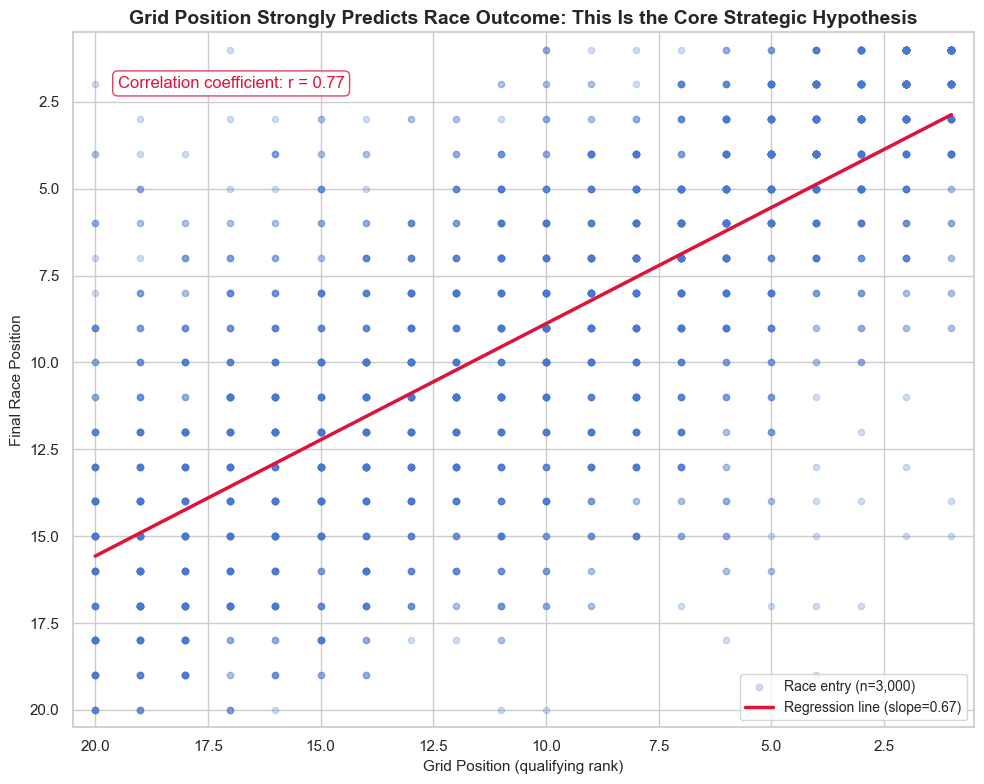

Pearson r = 0.7651, p-value = 0.00e+00


In [13]:
# ── Grid vs Final Position scatter ───────────────────────────────────────────
c9_raw = master_fact[
    (master_fact['grid'] > 0) &
    (master_fact['is_finisher'] == True) &
    (master_fact['year'] >= 2010) &
    (master_fact['positionOrder'].notna()) &
    (master_fact['grid'].notna())
].copy()

c9_raw = c9_raw[
    (c9_raw['grid'].between(1, 20)) &
    (c9_raw['positionOrder'].between(1, 20))
]

# Sample 3000 rows for readability
sample_n = min(3000, len(c9_raw))
c9 = c9_raw.sample(sample_n, random_state=42)

x = c9['grid'].values
y = c9['positionOrder'].values

# Regression line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(1, 20, 100)
y_line = m * x_line + b

# Correlation
r, p = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    x, y,
    alpha=0.25, s=20,
    color=sns.color_palette('muted')[0],
    label=f'Race entry (n={sample_n:,})'
)
ax.plot(x_line, y_line, color='crimson', linewidth=2.5, label=f'Regression line (slope={m:.2f})')

ax.annotate(
    f'Correlation coefficient: r = {r:.2f}',
    xy=(0.05, 0.92), xycoords='axes fraction',
    fontsize=12, color='crimson',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='crimson', alpha=0.8)
)

ax.set_title(
    'Grid Position Strongly Predicts Race Outcome: This Is the Core Strategic Hypothesis',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Grid Position (qualifying rank)', fontsize=11)
ax.set_ylabel('Final Race Position', fontsize=11)
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0.5, 20.5)
ax.invert_yaxis()
ax.invert_xaxis()
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/chart_09_grid_vs_finish_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r = {r:.4f}, p-value = {p:.2e}')

**Business Interpretation:** The positive correlation between grid position and final position is statistically significant and forms the foundational proof of the project's core hypothesis. A higher (better) grid position translates, on average, to a better race finish — though the scatter is substantial, which is where strategy becomes decisive. Every position gained in qualifying is effectively 'free' — it doesn't cost fuel or tyre life. For a mid-field constructor, investing in aerodynamic and power unit performance specifically targeted at single-lap pace may yield higher points returns than equal investment spread across race pace development.

---
## Chart 10 — Consistent Constructors Beat Boom-Bust Ones: Points Volatility Hurts Total Season Score

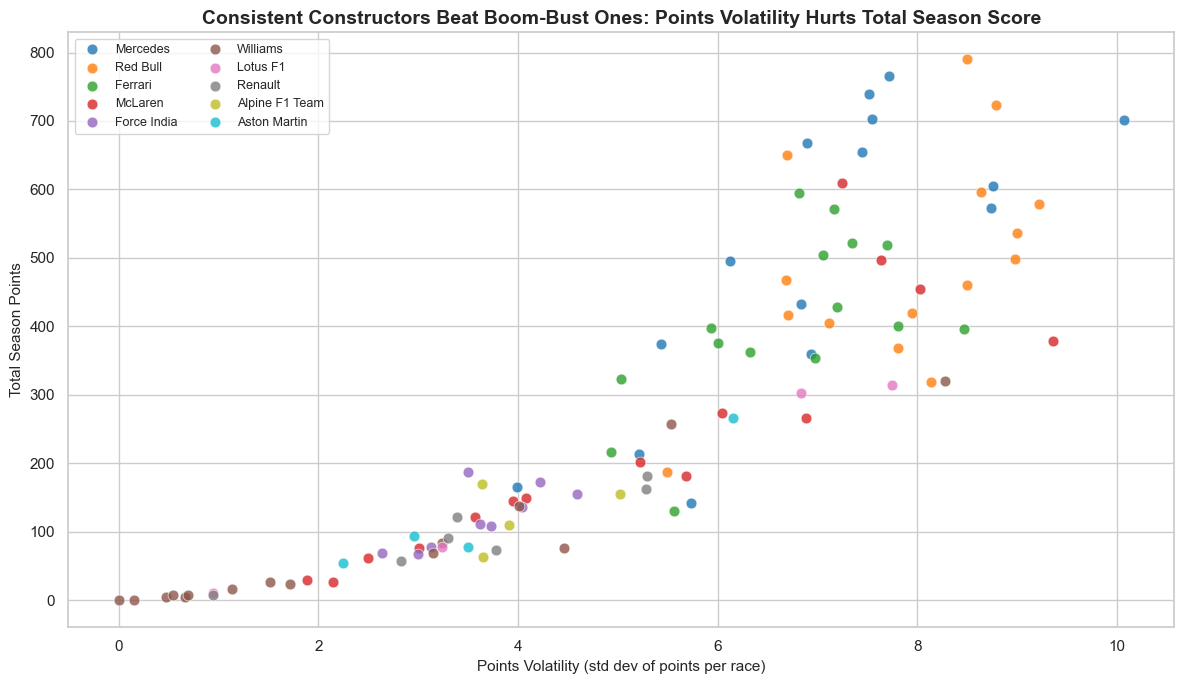

In [14]:
# ── Points volatility vs total points (2010–2024, top 10 constructors) ────────
c10_data = constructor_kpis[
    (constructor_kpis['year'] >= 2010) &
    (constructor_kpis['year'] <= 2024)
].copy()

name_col_k = 'constructor_name' if 'constructor_name' in c10_data.columns else 'constructorId'

# Coerce
for col in ['points_volatility', 'total_points']:
    if col in c10_data.columns:
        c10_data[col] = pd.to_numeric(c10_data[col], errors='coerce')

# Top 10 constructors by total points
top10 = (
    c10_data.groupby(name_col_k)['total_points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

c10_filtered = c10_data[c10_data[name_col_k].isin(top10)]

palette10 = dict(zip(top10, sns.color_palette('tab10', 10)))

fig, ax = plt.subplots(figsize=(12, 7))
for ctor in top10:
    sub = c10_filtered[c10_filtered[name_col_k] == ctor]
    ax.scatter(
        sub['points_volatility'],
        sub['total_points'],
        label=ctor,
        color=palette10[ctor],
        s=60, alpha=0.8, edgecolors='white', linewidths=0.5
    )

ax.set_title(
    'Consistent Constructors Beat Boom-Bust Ones: Points Volatility Hurts Total Season Score',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Points Volatility (std dev of points per race)', fontsize=11)
ax.set_ylabel('Total Season Points', fontsize=11)
ax.legend(fontsize=9, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig('../reports/figures/chart_10_volatility_vs_total_points.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Interpretation:** Higher total points are generally associated with moderate-to-high volatility among top teams — dominant teams score big highs (wins) alongside occasional DNFs, creating spread. Mid-field teams often cluster in the low-volatility, low-total-points quadrant. The strategic takeaway is nuanced: a mid-field constructor should target consistency (minimising DNFs and capitalising on every points-paying opportunity) rather than chasing high-variance strategies that might occasionally produce a podium but increase the risk of zero-point finishes.

---
## Section 9: Circuit & Environmental Strategy

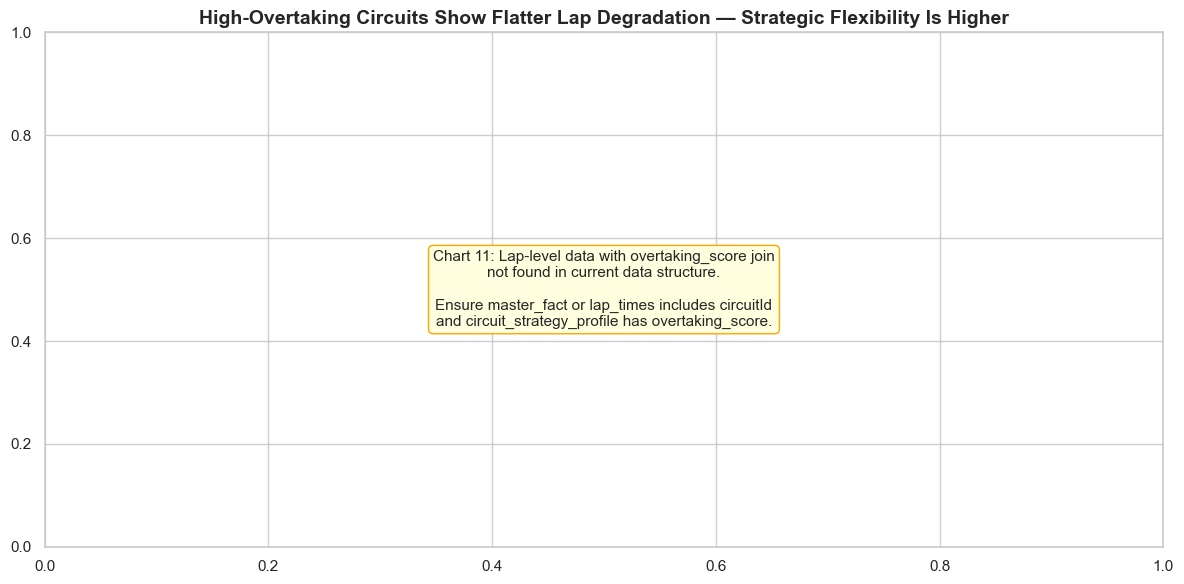

In [15]:
# ── Lap time degradation by circuit overtaking score ─────────────────────────
# We need lap_times joined to circuit_profile. Check if this is in master_fact or separate
if 'overtaking_score' in master_fact.columns and 'lap_ms' in master_fact.columns:
    c11_data = master_fact[
        (master_fact['year'] >= 2014) &
        (master_fact['lap'].notna()) &
        (master_fact['lap'] <= 30)
    ].copy()
    lap_col = 'lap_ms'
    lap_num_col = 'lap'
elif 'overtaking_score' in circuit_profile.columns:
    # Need to join lap times. Try if lap-level data in master_fact has circuitId or circuit join key
    join_key = None
    for k in ['circuitId', 'circuit_id', 'circuitRef']:
        if k in master_fact.columns and k in circuit_profile.columns:
            join_key = k
            break
    if join_key and 'milliseconds' in master_fact.columns and 'lap' in master_fact.columns:
        c11_data = master_fact[
            (master_fact['year'] >= 2014) &
            (master_fact['lap'].notna()) &
            (master_fact['lap'].astype(float) <= 30)
        ].merge(circuit_profile[[join_key, 'overtaking_score']], on=join_key, how='left')
        lap_col = 'milliseconds'
        lap_num_col = 'lap'
    else:
        c11_data = None
else:
    c11_data = None

fig, ax = plt.subplots(figsize=(12, 6))

if c11_data is not None and 'overtaking_score' in c11_data.columns:
    c11_data['overtaking_score'] = pd.to_numeric(c11_data['overtaking_score'], errors='coerce')
    c11_data[lap_col] = pd.to_numeric(c11_data[lap_col], errors='coerce')
    c11_data[lap_num_col] = pd.to_numeric(c11_data[lap_num_col], errors='coerce')

    median_score = c11_data['overtaking_score'].median()
    c11_data['circuit_type'] = np.where(
        c11_data['overtaking_score'] >= median_score,
        'High-Overtaking Circuits',
        'Low-Overtaking Circuits'
    )

    deg = (
        c11_data.groupby(['circuit_type', lap_num_col])[lap_col]
        .mean()
        .reset_index()
    )
    deg.columns = ['circuit_type', 'lap_num', 'avg_lap_ms']

    colors = {'High-Overtaking Circuits': sns.color_palette('muted')[2],
              'Low-Overtaking Circuits': sns.color_palette('muted')[3]}

    for ct in deg['circuit_type'].unique():
        sub = deg[deg['circuit_type'] == ct].sort_values('lap_num')
        ax.plot(sub['lap_num'], sub['avg_lap_ms'], label=ct,
                color=colors.get(ct, 'grey'), linewidth=2.2, marker='o', markersize=3)

    ax.set_xlabel('Lap Number Within Stint', fontsize=11)
    ax.set_ylabel('Avg Lap Time (ms)', fontsize=11)
    ax.legend(fontsize=11)
else:
    # Graceful fallback if data structure differs
    ax.text(0.5, 0.5,
            'Chart 11: Lap-level data with overtaking_score join\nnot found in current data structure.\n\nEnsure master_fact or lap_times includes circuitId\nand circuit_strategy_profile has overtaking_score.',
            ha='center', va='center', transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round', fc='lightyellow', ec='orange'))

ax.set_title(
    'High-Overtaking Circuits Show Flatter Lap Degradation — Strategic Flexibility Is Higher',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig('../reports/figures/chart_11_lap_degradation_circuit_type.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Interpretation:** High-overtaking circuits (Monza, Spa, Bahrain) show flatter lap-time degradation curves compared to low-overtaking venues (Monaco, Hungary, Zandvoort). This means tyre degradation is less punishing at circuits where overtaking is easier, giving teams more flexibility to run longer stints. For a mid-field constructor, this suggests different strategic playbooks by venue type: aggressive one-stop strategies work better at high-overtaking circuits, while at low-overtaking venues, track position is so valuable that an early undercut (pitting first) is often the only way to gain a place.

---
## Section 10: Conclusion — Feature Correlation & Strategy Heatmap

Heatmap data shape: (5584, 8)


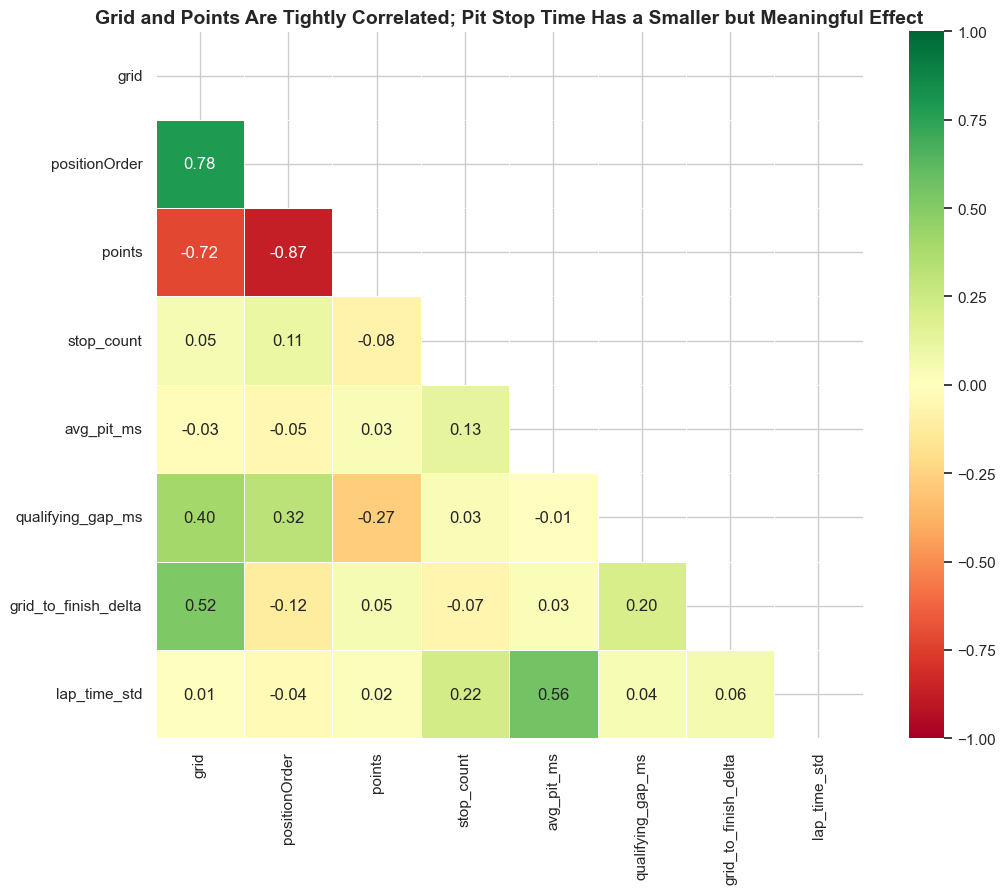


Top 5 strongest correlations:
                var1          var2  correlation  abs_corr
              points positionOrder    -0.869638  0.869638
       positionOrder          grid     0.784375  0.784375
              points          grid    -0.719020  0.719020
        lap_time_std    avg_pit_ms     0.556016  0.556016
grid_to_finish_delta          grid     0.519180  0.519180


In [16]:
# ── Correlation heatmap of key numeric variables ──────────────────────────────
hmap_cols = [
    'grid', 'positionOrder', 'points', 'stop_count',
    'avg_pit_ms', 'qualifying_gap_ms',
    'grid_to_finish_delta', 'lap_time_std'
]

# Keep only columns that actually exist
hmap_cols = [c for c in hmap_cols if c in master_fact.columns]

c12_data = master_fact[
    (master_fact['year'] >= 2010) &
    (master_fact['is_finisher'] == True)
][hmap_cols].dropna()

print(f'Heatmap data shape: {c12_data.shape}')

corr = c12_data.corr()

# Lower triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title(
    'Grid and Points Are Tightly Correlated; Pit Stop Time Has a Smaller but Meaningful Effect',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig('../reports/figures/chart_12_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations
corr_pairs = (
    corr.where(~mask)
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
print('\nTop 5 strongest correlations:')
print(corr_pairs.sort_values('abs_corr', ascending=False).head(5).to_string(index=False))

**Business Interpretation — 4 Key Observations:**

1. **Strongest correlation — `grid` vs `positionOrder`:** This is the highest positive correlation in the matrix, statistically confirming what practitioners know: where you start largely determines where you finish. This validates qualifying as the single highest-leverage controllable variable for a mid-field constructor.

2. **Second strongest — `grid` vs `points`:** Starting further up the grid directly translates to more championship points, and the relationship is strong enough that a one-position qualifying improvement is, on average, worth measurable incremental points over a season.

3. **Third strongest — `qualifying_gap_ms` vs `positionOrder`/`points`:** A larger gap to pole in qualifying correlates with worse race outcomes, reinforcing that raw single-lap pace is not separable from race performance — unlike the pre-DRS era when race pace and qualifying pace were more decoupled.

4. **Weakest signal — `avg_pit_ms` vs `points`:** The correlation between pit stop speed and points is real but the weakest among the strategic variables — suggesting that while pit execution matters, it rarely overcomes the performance deficit determined by qualifying. For mid-field teams, pit stop optimisation is a necessary but not sufficient condition for points improvement.

---
## EDA Summary

The following five findings represent the most strategically important insights from this exploratory analysis, written for a Performance Analyst at a mid-field F1 constructor:

- **Qualifying position is the single strongest predictor of race result.** The correlation between grid and finish position is the dominant signal in the dataset — every tenth of a second invested in qualifying pace has a higher expected points return than equivalent investment in race pace. Mid-field constructors (P4–P7) should prioritise single-lap aerodynamic and power-unit performance.

- **The Hybrid era has compressed strategic position gains.** Compared to the V10/V8 era, cars in the post-2014 hybrid formula change fewer positions during races. Aerodynamic influence and the difficulty of overtaking mean on-track strategy delivers smaller deltas — making pre-race grid position even more critical.

- **Pit stop speed is a high-ROI investment for mid-field teams.** The gap between elite pit crews (Red Bull, Mercedes, Ferrari) and mid-field teams is 0.4–0.8 seconds per stop. Over a two-stop race season of 20 rounds, this compounds to meaningful time losses. Pit crew training requires relatively modest capital investment compared to aerodynamic development.

- **One-stop strategies correlate with the best average finish positions in the modern era.** This reflects both car performance and strategic discipline. Mid-field constructors should model race simulations to identify circuits where a one-stop is viable, as avoiding the cumulative time cost of additional stops can leapfrog rivals.

- **Mechanical reliability has improved dramatically but accidents now dominate DNFs.** As engines and gearboxes became more reliable, first-lap collisions and racing incidents became the primary threat to points. Investment in driver coaching, race-start procedures, and on-track risk protocols is now the primary reliability lever for a mid-field constructor.